한글 깨짐 방지.

In [1]:
# 한글 깨짐 방지, 설치 후 런타임 재시작
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 20 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (17.5 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 124926 files and direc

#GitHub Repository & library


In [1]:
!git clone https://github.com/zzuupp/-Screen-Wizard.git

Cloning into '-Screen-Wizard'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 86 (delta 21), reused 76 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (86/86), 5.12 MiB | 19.65 MiB/s, done.
Resolving deltas: 100% (21/21), done.


In [2]:
%ls

sample_data/  -Screen-Wizard/


In [3]:
%cd /content/-Screen-Wizard/

/content/-Screen-Wizard


In [4]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [5]:
!git pull origin main

From https://github.com/zzuupp/-Screen-Wizard
 * branch            main       -> FETCH_HEAD
Already up to date.


In [6]:
! git branch -r

  origin/Data/DATA-EDA
  origin/Data/cleansing-collect
  origin/HEAD -> origin/main
  origin/main


In [7]:
! git switch Data/DATA-EDA

Branch 'Data/DATA-EDA' set up to track remote branch 'Data/DATA-EDA' from 'origin'.
Switched to a new branch 'Data/DATA-EDA'


In [8]:
!git branch

* Data/DATA-EDA
  main


In [9]:
!git pull origin Data/DATA-EDA

From https://github.com/zzuupp/-Screen-Wizard
 * branch            Data/DATA-EDA -> FETCH_HEAD
Already up to date.


한글 깨짐 방지.

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
import scipy.stats as stats
from scipy.stats import shapiro
import matplotlib.ticker as ticker

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN


# plt 마이너스 부호 방지
import matplotlib as mpl

# FuncFormatter 처음써봄
#축에 표시되는 숫자 값을 특정 형식으로 변환 가능
#예: 지수 표기법을 일반 숫자로 변환, 숫자를 백만 단위(M)로 변경, 퍼센트(%)로 표시 등
from matplotlib.ticker import FuncFormatter

# 한글 깨짐 방지, 상단 코드셀 실행후 런타임 재시작 이후 현재 코드셀 진행.
plt.rcParams['font.family'] = 'NanumBarunGothic'

# 마이너스 부호 방지.
mpl.rcParams['axes.unicode_minus'] = False

데이터 가져오기.

In [11]:
kobis = pd.read_csv('/content/-Screen-Wizard/Data/processed/Kobis_data/filtered_kobis.csv')
before_boxoffice = pd.read_csv('/content/-Screen-Wizard/Data/processed/before/filtered_before_boxoffice.csv')
after_boxoffice = pd.read_csv('/content/-Screen-Wizard/Data/processed/after/filtered_after_boxoffice.csv')

#### kobis 데이터 무비코드 재연결 및 박스오피스 데이터 합치기.

In [12]:
# boxoffice 데이터 병합.
boxoffice  = pd.concat([before_boxoffice, after_boxoffice])

# 날짜 형태 변경
boxoffice['openDt'] = pd.to_datetime(boxoffice['openDt'])

# 필요없는 컬럼 버리기.
boxoffice.drop(columns = ['rnum'])


# 박스오피스 필터링 : 영화이름(고유 및 최대 금액)
highest_boxoffice = boxoffice.loc[boxoffice.groupby(['movieNm', 'openDt','movieCd'])['salesAcc'].idxmax()]

# kobis 날짜 형태 변경
kobis['개봉일'] = pd.to_datetime(kobis['개봉일'])

# 코비스 : 무비코드 다시 맞추기.
filtered_kobis = kobis.merge(highest_boxoffice[['movieNm','openDt','movieCd']],
                             left_on =['영화명', '개봉일'],
                             right_on = ['movieNm', 'openDt'],
                             how = 'left')


# 무비코드 값 채우기.
filtered_kobis['영화코드'] = filtered_kobis['movieCd']

# 원본 kobis를 유지하기 위한 'movieNm', 'openDt', 'movieCd' 컬럼 삭제
filtered_kobis = filtered_kobis.drop(columns = ['movieCd', 'movieNm', 'openDt'])

# 무비코드가 존재하는 코비스 데이터.
filtered_kobis = filtered_kobis[filtered_kobis['영화코드'].notna()]

# 컬럼 이름 변경
filtered_kobis = filtered_kobis.rename(columns={'전국_스크린수':'전국스크린수',
                   '전국_매출액':'전국매출액',
                   '전국_관객수':'전국관객수',
                   '서울_매출액':'서울매출액',
                   '서울_관객수':'서울관객수'})


####[컬럼정보] BoxOffice
```
'rnum'  : 순번 출력.
'rank'  : 해당일자의 박스오피스 순위
'rankInten' :  전일대비 순위의 증감분 출력.
'rankOldAndNew' : 랭킹에 신규진입여부를 출력합니다. => “OLD” : 기존 , “NEW” : 신규
'movieCd'    : 영화의 대표코드를 출력
'movieNm'    : 영화명(국문)을 출력
'openDt'     : 영화의 개봉일을 출력
'salesAmt'   : 해당일의 매출액을 출력
'salesShare' : 해당일자 상영작의 매출총액 대비 해당 영화의 매출비율을 출력
'salesInten' : 전일 대비 매출액 증감분을 출력
'salesChange': 전일 대비 매출액 증감 비율을 출력
'salesAcc'   : 누적매출액을 출력
'audiCnt'    : 해당일의 관객수를 출력
'audiInten'  : 전일 대비 관객수 증감분을 출력
'audiChange' : 전일 대비 관객수 증감 비율을 출력
'audiAcc'    : 누적관객수를 출력
'scrnCnt'    : 해당일자에 상영한 스크린수를 출력
'showCnt'    : 해당일자에 상영된 횟수를 출력

```

# EDA

## 1️⃣ 흥행의 기준 잡기

1. 분위수를 이용한 흥행 기준 설정
2. 절대적인 기준을 이용한 흥행 판단

### １-１. 분위수를 이용한 흥행 기준


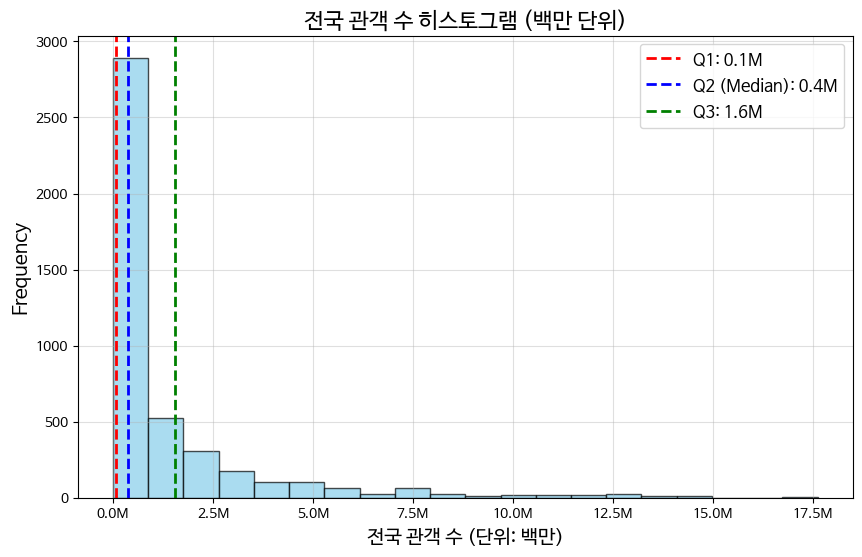

In [13]:
# 확인할 부분 : 전국관객수
data = filtered_kobis["전국관객수"]

# 분위수 계산
q1 = data.quantile(0.25) # 1사분위 수
q2 = data.quantile(0.50) # 2사분위 수
q3 = data.quantile(0.75) # 3사분위 수

# 사이즈
plt.figure(figsize = (10,6))

# 구간 데이터 개수, 구간 결정값, 각 구간 막대 개체 생성(n, bins, patches)
n, bins, patches = plt.hist(data,
                            bins = 20,
                            color = 'skyblue',
                            alpha = 0.7,
                            edgecolor = 'black')


# 수직선(분위 수) 추가
plt.axvline(q1, color = 'red',
            linestyle = '--',
            linewidth = 2,
            label = f'Q1: {q1 / 1e6:.1f}M')

plt.axvline(q2, color = 'blue',
            linestyle = '--',
            linewidth = 2,
            label = f'Q2 (Median): {q2 / 1e6:.1f}M')

plt.axvline(q3, color = 'green',
            linestyle = '--',
            linewidth = 2,
            label = f'Q3: {q3 / 1e6:.1f}M')

#원하는 축의 단위 변경 -> 백만단위로 축소
def format_millions(x, pos):
    return f'{x * 1e-6:.1f}M'

# set_major_formatter : 원하는 축 설정
# FuncFormatter() : 클래스의 인스턴스 객체 생성.
# 정의 함수 format_millions를 이용하여 축 레이블 변환(xaxis -> 레이블)
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_millions))

# 그래프 설정(레이블, 제목...)
# ✅ 그래프 레이블 및 제목 설정
plt.title("전국 관객 수 히스토그램 (백만 단위)", fontsize=16)
plt.xlabel("전국 관객 수 (단위: 백만)", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

# 범례 : 오른쪽 위 표기.
plt.legend(loc="upper right", fontsize=12)
plt.grid(alpha=0.4)
plt.show()

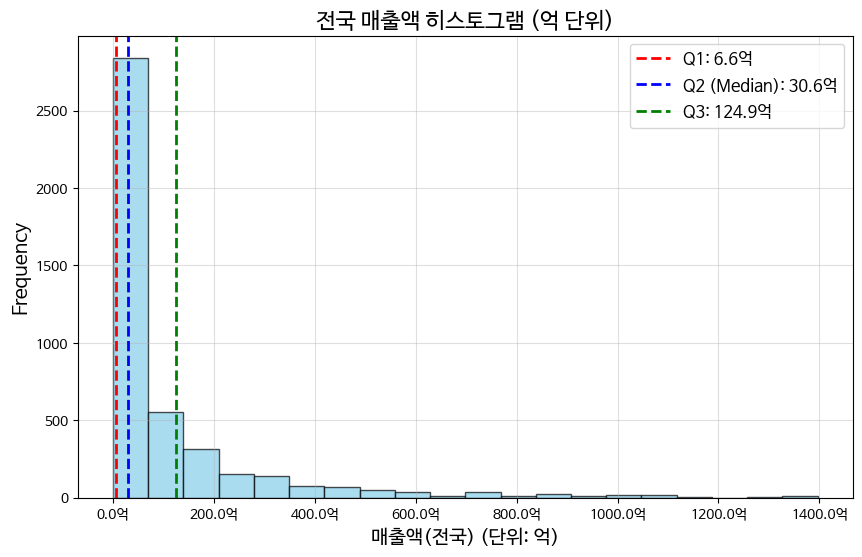

In [14]:
data = filtered_kobis["전국매출액"]

# 분위수 계산(억단위 변경 * 1e-8)
q1 = data.quantile(0.25)  # 1억단위
q2 = data.quantile(0.50) # 1억단위
q3 = data.quantile(0.75) # 1억단위

# 사이즈
plt.figure(figsize = (10,6))

# 구간 데이터 개수, 구간 결정값, 각 구간 막대 개체 생성(n, bins, patches)
n, bins, patches = plt.hist(data ,
                            bins = 20,
                            color = 'skyblue',
                            alpha = 0.7,
                            edgecolor = 'black')


# 수직선(분위 수) 추가
plt.axvline(q1, color = 'red',
            linestyle = '--',
            linewidth = 2,
            label = f'Q1: {q1 / 1e8:.1f}억')

plt.axvline(q2, color = 'blue',
            linestyle = '--',
            linewidth = 2,
            label = f'Q2 (Median): {q2 / 1e8:.1f}억')

plt.axvline(q3, color = 'green',
            linestyle = '--',
            linewidth = 2,
            label = f'Q3: {q3 / 1e8:.1f}억')

#원하는 축의 단위 변경 -> 백만단위로 축소
def format_billions(x, pos):
    return f'{x / 1e8:.1f}억'

# set_major_formatter : 원하는 축 설정
# FuncFormatter() : 클래스의 인스턴스 객체 생성.
# 정의 함수 format_millions를 이용하여 축 레이블 변환(xaxis -> 레이블)
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_billions))

# 그래프 설정(레이블, 제목...)
# ✅ 그래프 레이블 및 제목 설정
plt.title("전국 매출액 히스토그램 (억 단위)", fontsize=16)
plt.xlabel("매출액(전국) (단위: 억)", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

# 범례 : 오른쪽 위 표기.
plt.legend(loc="upper right", fontsize=12)
plt.grid(alpha=0.4)
plt.show()

### １-２. 절대적 기준 잡기(정해야함)

## 2️⃣ 장르별 매출 및 관객 동향

### ２-１. 장르별 관객 동원수
* 전국관객수에 NaN이 값이 존재한다면 제외합니다.

In [15]:
# 전국관객수에 NaN값 확인하기.
count_nan = filtered_kobis['전국관객수'].isna().sum()
print(f"'전국관객수' 컬럼의 NaN 개수: {count_nan}")

count_3 = (filtered_kobis['전국관객수'] <= 3).sum()
print(f"'전국관객수'가 3인 개수: {count_3}")

'전국관객수' 컬럼의 NaN 개수: 0
'전국관객수'가 3인 개수: 1


In [16]:
filtered_kobis[filtered_kobis['전국관객수']==3]

,영화명,감독,제작사,수입사,배급사,개봉일,영화유형,영화형태,국적,전국스크린수,전국매출액,전국관객수,서울매출액,서울관객수,장르,등급,영화구분,영화코드
13859,킬러의 보디가드 무삭제 특별판,패트릭 휴즈,NaN,(유)조이앤시네마,"(주)제이앤씨미디어그룹,(유)조이앤시네마",2018-09-12,개봉영화,장편,미국,3,3000,3,1000,1,액션,청소년관람불가,일반영화,20189987


In [17]:
fig = px.box(
    filtered_kobis,
    x="장르",
    y="전국관객수",
    color="장르",  # 색상을 장르별로 다르게 적용
    points="all",  # 이상치(outliers) 표시
    title="🎬 장르별 동원 관객수 (전국)",
    hover_data=["영화명"], # 마우스 커서 올려 놓을 때 표기.
    color_discrete_sequence=px.colors.qualitative.Bold  # 색상 팔레트 설정
)

# 레이아웃 스타일 조정
fig.update_layout(
    xaxis_title=" 영화 장르",
    xaxis_tickangle = -45, #x축 기울이기.
    yaxis_title="👥 전국 관객 수",
    font=dict(size=14),  # 폰트 크기 조정
    plot_bgcolor="lightgray",  # 그래프 내부 배경 색상 설정
    paper_bgcolor="whitesmoke"  # 전체 배경 색상 설정
)

# 그래프 출력
fig.show()

#### ２-１. INSIGHT
* 생각외로 사극의 박스플롯의 박스가 크게 분포 되어 있음.
    * 이상치(수염 아래)에 분포된 영화들 또한 많이 보인다(사극)
* 특정 **장르가 관객수를 독점하고 있을 상황이 높다.**
    * 드라마, 액션, 애니메이션, 범죄, 코미디.

#### ２-１-１. 데이터 필터링 : 특정 장르별 크게 흥행한 영화 데이터 살펴보기(이상치)
> ❗️특정 장르별 수염 위로 위치한, 즉 흥행한 영화들만을 필터링 하여 가져옵니다.

In [18]:
highest_outlier_genre = filtered_kobis[filtered_kobis['장르'].isin(
    ['드라마', '액션', '애니메이션', '범죄', '코미디'])]

duplicate_count = highest_outlier_genre.duplicated().sum()
print(f"중복된 행의 개수: {duplicate_count}")

중복된 행의 개수: 1355


In [19]:
duplicates = highest_outlier_genre[highest_outlier_genre.duplicated(keep=False)]
print(duplicates)

               영화명      감독                  제작사          수입사        배급사  \
4             국제시장     윤제균  (주)제이케이필름,(주)씨제이이엔엠          NaN  (주)씨제이이엔엠   
5             국제시장     윤제균  (주)제이케이필름,(주)씨제이이엔엠          NaN  (주)씨제이이엔엠   
6             국제시장     윤제균  (주)제이케이필름,(주)씨제이이엔엠          NaN  (주)씨제이이엔엠   
7             국제시장     윤제균  (주)제이케이필름,(주)씨제이이엔엠          NaN  (주)씨제이이엔엠   
8             국제시장     윤제균  (주)제이케이필름,(주)씨제이이엔엠          NaN  (주)씨제이이엔엠   
...            ...     ...                  ...          ...        ...   
6250  라라와 크리스마스 요정     NaN                  NaN  주식회사 디에스이이디  (주)트리플픽쳐스   
6314             걸  루카스 돈트                  NaN      주식회사 더쿱  (주)리틀빅픽쳐스   
6315             걸  루카스 돈트                  NaN      주식회사 더쿱  (주)리틀빅픽쳐스   
6803            호프  마리아 소달                  NaN     (주)이놀미디어   (주)이놀미디어   
6804            호프  마리아 소달                  NaN     (주)이놀미디어   (주)이놀미디어   

            개봉일  영화유형 영화형태    국적  전국스크린수         전국매출액     전국관객수        서울매출액  \
4    2014-12-17  개

In [21]:
# 중복된 데이터 삭제.
highest_outlier_genre_unique = highest_outlier_genre.drop_duplicates(keep='first')

### ２-２. IQR Method
> IQR 탐지로 수염위에 존재하는 데이터 살펴보기

In [23]:
# 이상치 기준 계산
# Q1, Q3, IQR 및 상한선 계산

q1 = highest_outlier_genre_unique.groupby('장르')['전국관객수'].quantile(0.25)
q3 = highest_outlier_genre_unique.groupby('장르')['전국관객수'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

#  이상치 데이터 추출
highest_outliers = highest_outlier_genre_unique[
    (highest_outlier_genre_unique['전국관객수'] > upper_bound[highest_outlier_genre_unique['장르']].values)
]

highest_outliers

,영화명,감독,제작사,수입사,배급사,개봉일,영화유형,영화형태,국적,전국스크린수,전국매출액,전국관객수,서울매출액,서울관객수,장르,등급,영화구분,영화코드
2,극한직업,이병헌,"(주)어바웃잇,영화사 해그림 주식회사,(주)씨제이이엔엠",NaN,(주)씨제이이엔엠,2019-01-23,개봉영화,장편,한국,1978,139647979516,16264944,31858660536,3638287,코미디,15세이상관람가,일반영화,20182530
4,국제시장,윤제균,"(주)제이케이필름,(주)씨제이이엔엠",NaN,(주)씨제이이엔엠,2014-12-17,개봉영화,장편,한국,966,110828014630,14245998,25842519330,3233946,드라마,12세이상관람가,일반영화,20137048
12,어벤져스: 엔드게임,"안소니 루소,조 루소",NaN,월트디즈니컴퍼니코리아 유한책임회사,월트디즈니컴퍼니코리아 유한책임회사,2019-04-24,개봉영화,장편,미국,2835,122182694160,13934592,33577136860,3597963,액션,12세이상관람가,일반영화,20184889
13,겨울왕국 2,"크리스 벅,제니퍼 리",NaN,월트디즈니컴퍼니코리아 유한책임회사,월트디즈니컴퍼니코리아 유한책임회사,2019-11-21,개봉영화,장편,미국,2648,114810421450,13747792,28824682580,3225974,애니메이션,전체관람가,일반영화,20197803
15,베테랑,류승완,"(주)외유내강,(주)필름케이",NaN,(주)씨제이이엔엠,2015-08-05,개봉영화,장편,한국,1064,105024756250,13395400,26766369950,3290366,액션,15세이상관람가,일반영화,20148048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1561,극장판 짱구는 못말려: 수수께끼! 꽃피는 천하떡잎학교,타카하시 와타루,NaN,(주)씨제이이엔엠,(주)씨제이이엔엠,2022-09-28,개봉영화,장편,일본,873,8370741924,837647,1475548813,140884,애니메이션,전체관람가,일반영화,20226777
1569,장화신은 고양이: 끝내주는 모험,조엘 크로포드,NaN,유니버설픽쳐스인터내셔널 코리아(유),유니버설픽쳐스인터내셔널 코리아(유),2023-01-04,개봉영화,장편,미국,924,7872245363,831209,1765136461,178819,애니메이션,전체관람가,일반영화,20224109
1574,뽀로로 극장판 공룡섬 대모험,"김현호,윤제완",(주)오콘,NaN,(주)넥스트엔터테인먼트월드(NEW),2017-12-07,개봉영화,장편,한국,803,6203897300,824079,1093529800,137767,애니메이션,전체관람가,일반영화,20174846
1579,레드슈즈,홍성호,(주)싸이더스,NaN,(주)넥스트엔터테인먼트월드(NEW),2019-07-25,개봉영화,장편,한국,717,6102923190,817547,1380911550,201881,애니메이션,전체관람가,일반영화,20198323


#### ２-２-１. 이상치(수염위) 존재하는 장르별 영화 데이터 그래프.


In [24]:
outlier_genre_summary = highest_outliers.groupby('장르').agg(
    영화개수=('영화명', 'count'),
    최대관객수=('전국관객수', 'max'),
    최소관객수=('전국관객수', 'min'),
    평균관객수=('전국관객수', 'mean'),
    매출평균=('전국매출액', 'mean')
).reset_index()

# 평균관객수(백만 단위) 변환
outlier_genre_summary['평균관객수 (백만)'] = (outlier_genre_summary['평균관객수'] / 1e6).round(3)

# 최다관객수 (백만 단위) 변환
outlier_genre_summary['최대관객수 (백만)'] = (outlier_genre_summary['최대관객수'] / 1e6).round(3)

# 최소관객수 (십만 단위) 변환
outlier_genre_summary['최소관객수 (십만)'] = (outlier_genre_summary['최소관객수'] / 1e5).round(3)

# 매출평균(억 단위) 변환
outlier_genre_summary['매출평균 (억)'] = (outlier_genre_summary['매출평균'] / 1e8).round(3)

# 기존 단위 컬럼 삭제 (원본 유지하고 싶다면 생략 가능)
outlier_genre_summary.drop(columns=['평균관객수', '매출평균', '최대관객수', '최소관객수'], inplace=True)


#"전체" 카테고리 추가하여 Sunburst 계층 구조 확장
outlier_genre_summary['전체'] = "전체 장르"  # 최상위 계층을 "전체 장르"로 설정


total_row = pd.DataFrame({
    '장르': ["전체 장르"],  # 부모 노드(최상위)
    '영화개수': [outlier_genre_summary['영화개수'].sum()],  # 전체 영화 개수 합산
    '평균관객수 (백만)': [outlier_genre_summary['평균관객수 (백만)'].mean()],  # 전체 매출 합산
    '매출평균 (억)': [outlier_genre_summary['매출평균 (억)'].mean()],
    '최대관객수 (백만)':[outlier_genre_summary['최대관객수 (백만)'].mean()],
    '최소관객수 (십만)':[outlier_genre_summary['최소관객수 (십만)'].mean()],
    '전체': [""],  # 최상위 노드이므로 부모 없음
})

sunburst_df = pd.concat([total_row, outlier_genre_summary], ignore_index=True)


In [25]:
sunburst_df

,장르,영화개수,평균관객수 (백만),매출평균 (억),최대관객수 (백만),최소관객수 (십만),전체
0,전체 장르,216,5.4014,454.0104,14.1774,29.8108,
1,드라마,76,3.7100,299.0680,14.2460,12.5890,전체 장르
2,범죄,9,7.6060,657.8270,12.6930,50.6360,전체 장르
3,애니메이션,71,2.3990,202.3390,13.7480,8.1400,전체 장르
4,액션,42,7.8670,682.2570,13.9350,51.4320,전체 장르
5,코미디,18,5.4250,428.5610,16.2650,26.2570,전체 장르


In [26]:
fig = px.sunburst(
    sunburst_df,
    path=['전체', '장르'],  # 계층 구조 확장 (전체 장르 → 개별 장르)
    values='영화개수',  # 영화 개수 기준으로 비율 표시
    hover_data={'평균관객수 (백만)': True, '매출평균 (억)': True},  # 마우스 오버 시 추가 정보 표시
    title="이상치 :장르별 평균 관객 및 매출",
    branchvalues="total"    # remainder :부모 노드가 자식 노드들의 합으로 자동 조정
)                            # total : 부모 노드가 자식 노드들의 합과 정확히 일치하는 경우

fig.show()

#### ２-２-２. 이상치(수염위)의 장르별(특정) 대표 영화

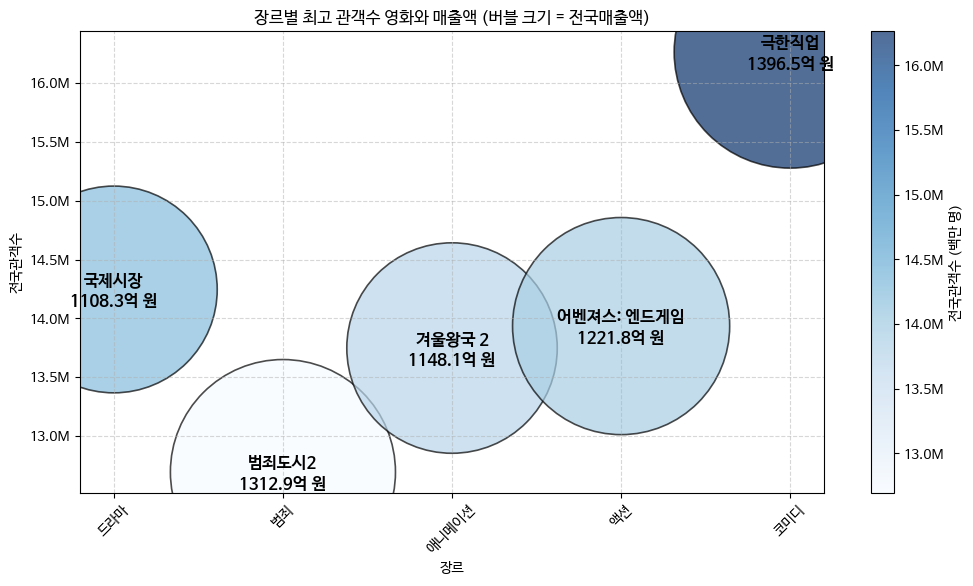

In [27]:
# 관객수 백만단위 변경함수
def millions(x, pos):
    return f'{x / 1e6:.1f}M'


def billions(x):
    return f'{x / 1e8:.1f}억 원'  # 100000000 → "10.0억 원"

plt.figure(figsize = (12,6))

# 큰값 가져오기
top_movies = highest_outliers.loc[highest_outliers.groupby('장르')['전국관객수'].idxmax()]

# 시각화
scatter = plt.scatter(top_movies['장르'], # x축
                      top_movies['전국관객수'], #y축
                      s = top_movies['전국매출액'] / 1e8 * 20, # 버블 크기 설정
                      c = top_movies['전국관객수'], #버블 색(관객수에 따라 다름)
                      cmap = 'Blues',
                      alpha = 0.7, # 투명도 설정
                      edgecolors= 'black',
                      linewidths=1.2)

# 영화 제목 출력(한행씩)
for i, row in top_movies.iterrows():
    y_offset = top_movies["전국관객수"].max() * 0.001
    movie_text = f"{row['영화명']}\n{billions(row['전국매출액'])}"  # 제목 + 매출액 줄바꿈 표시
    plt.text(row["장르"],
            row["전국관객수"] - y_offset,
            movie_text, fontsize=12,
            ha="center", va="center",
            color="black", fontweight="bold")


# 변경
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(millions))


# 컬러 바에도 백만 단위 적용
cbar = plt.colorbar(scatter, label="전국관객수 (백만 명)")
cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(millions))


plt.xlabel("장르")
plt.ylabel("전국관객수")
plt.title("장르별 최고 관객수 영화와 매출액 (버블 크기 = 전국매출액)")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)


plt.show()

### ２-３.이상치 영화의 흥행 성공 요인
* 이상치 영화의 흥행 성공 요인 구체적으로 분석하기.
    * 배급사, 제작사, 감독, 개봉일 등등
    * 특정 배급사가 반복적으로 흥행 성공에 기여했는지 여부 확인

#### ２-３-１.흥행한 영화의 배급사.

In [46]:
outlier_distributors = highest_outliers['배급사'].value_counts()
outlier_distributors

,count
배급사,
(주)씨제이이엔엠,54
(주)넥스트엔터테인먼트월드(NEW),25
월트디즈니컴퍼니코리아 유한책임회사,19
(주)쇼박스,18
유니버설픽쳐스인터내셔널 코리아(유),18
롯데컬처웍스(주)롯데엔터테인먼트,12
롯데쇼핑㈜롯데엔터테인먼트,8
플러스엠 엔터테인먼트,7
월트디즈니컴퍼니코리아(주),6


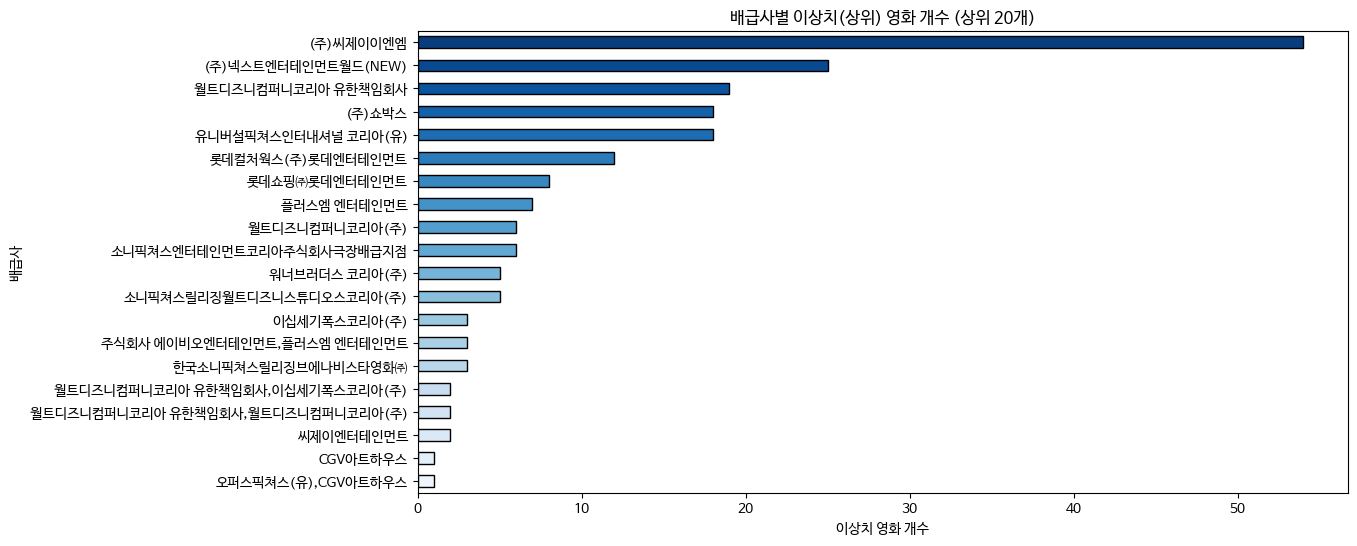

In [48]:
# (3) 배급사 또는 제작사별 이상치 영화 개수
# 배급사와 제작사별로 이상치 영화가 얼마나 많은지 시각화하여, 특정 배급사가 흥행에 강세인지 확인합니다.

# 데이터 정렬 (큰 값이 먼저 오도록 내림차순 정렬)
distributor_counts = highest_outliers['배급사'].value_counts().head(20).sort_values(ascending=False)

# 컬러맵 설정 (색상을 다양하게 적용)
colors = sns.color_palette("Blues", len(distributor_counts))[::-1]  # 색상순서변경

# 가로 막대 그래프 그리기
plt.figure(figsize=(12, 6))
distributor_counts.plot(kind='barh', color=colors, edgecolor='black')  # 개별 색상 적용
plt.title("배급사별 이상치(상위) 영화 개수 (상위 20개)")
plt.xlabel("이상치 영화 개수")
plt.ylabel("배급사")
plt.gca().invert_yaxis()  # 배급사 순서 유지 (내림차순 정렬 유지)
plt.show()



#### ２-３-２ 배급사별 장르 분포 확인하기(상위 배급사별 장르 비율)

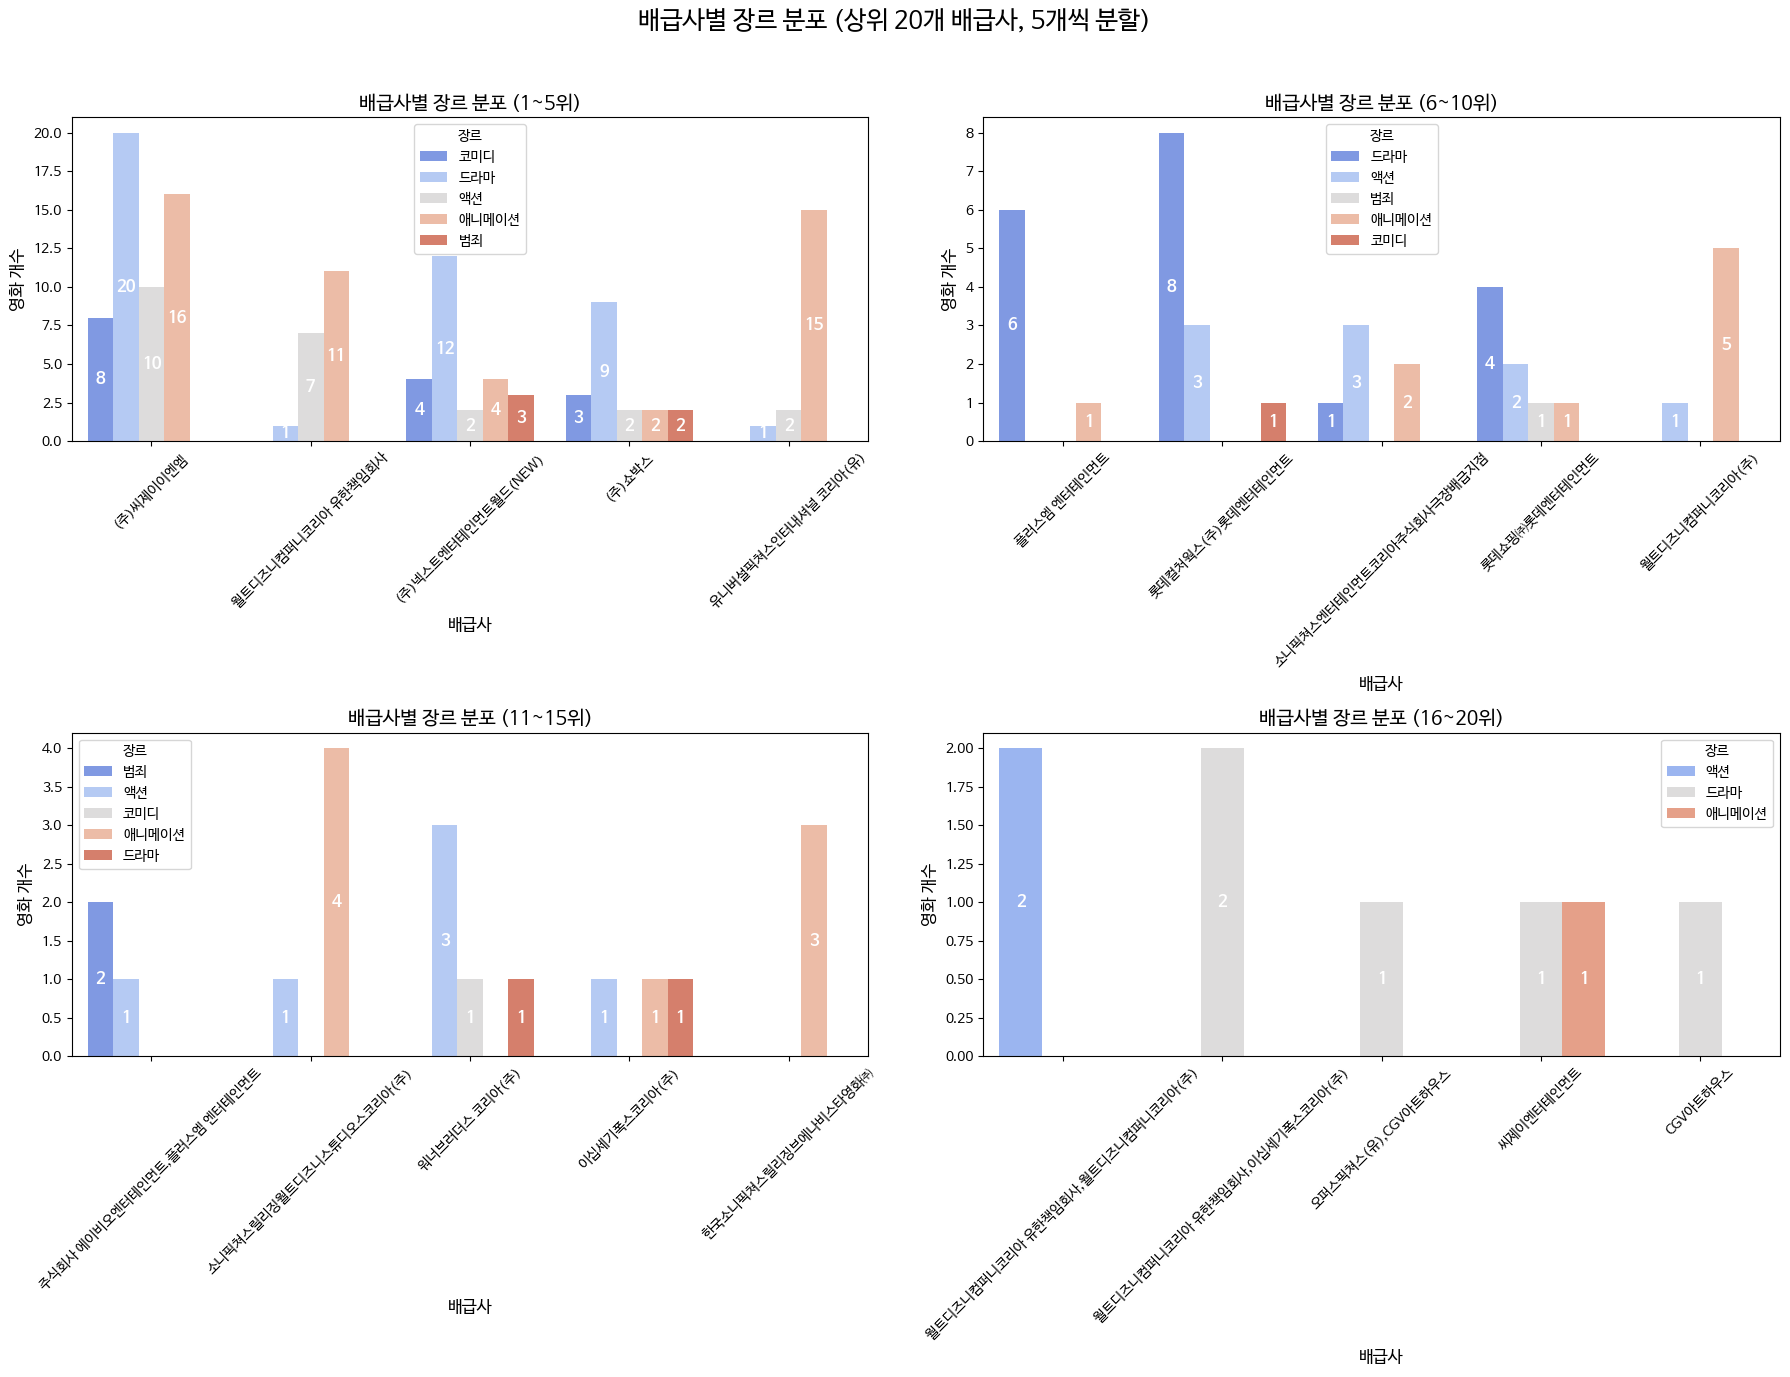

In [63]:
#  상위 20개 배급사 선택
top_distributors = distributor_counts.index[:20]

#  서브플롯 설정 (2*2 그리드, 총 4개 그래프, 크기 확대)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("배급사별 장르 분포 (상위 20개 배급사, 5개씩 분할)", fontsize=18)

# 배급사 5개씩 분할
for i, ax in enumerate(axes.flat):
    if i * 5 >= len(top_distributors):
        break
    selected_distributors = top_distributors[i * 5 : (i + 1) * 5]
    genre_distribution = highest_outliers[highest_outliers["배급사"].isin(selected_distributors)]

    # 배급사별 장르 분포 그래프
    plot = sns.countplot(data=genre_distribution, x="배급사", hue="장르", palette="coolwarm", ax=ax)

    # 막대 안에 총 영화 개수 추가
    for p in plot.patches:
        height = p.get_height()
        if height > 0:
            ax.text(
                p.get_x() + p.get_width() / 2,
                height / 2,
                f"{int(height)}",
                ha="center", va="center", fontsize=12, color="white", fontweight="bold"
            )

    # 서브플롯 설정
    ax.set_title(f"배급사별 장르 분포 ({i*5+1}~{(i+1)*5}위)", fontsize=14)
    ax.set_xlabel("배급사", fontsize=12)
    ax.set_ylabel("영화 개수", fontsize=12)

    # X축 눈금 고정 후 레이블 설정
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

    # 범례 자동 위치 조정 (빈 공간에 맞춰 배치)
    ax.legend(title="장르")

# 전체 레이아웃 조정
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


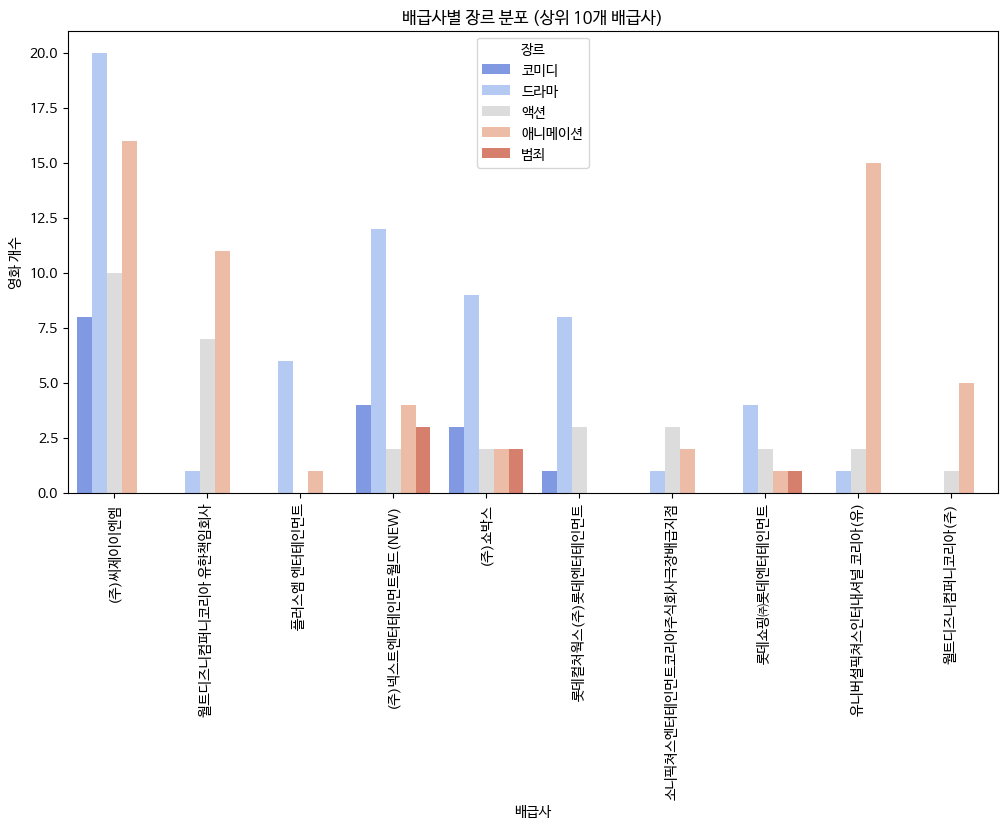

In [50]:
top_distributors = distributor_counts.index[:10]  # 상위 10개 배급사 선택
genre_distribution = highest_outliers[highest_outliers["배급사"].isin(top_distributors)]

plt.figure(figsize=(12, 6))
sns.countplot(data=genre_distribution, x="배급사", hue="장르", palette="coolwarm")
plt.title("배급사별 장르 분포 (상위 10개 배급사)")
plt.xlabel("배급사")
plt.ylabel("영화 개수")
plt.xticks(rotation=90)
plt.legend(title="장르")
plt.show()

#### ２-３-３. 이상치(수염위) 배급사별 매출확인하기.


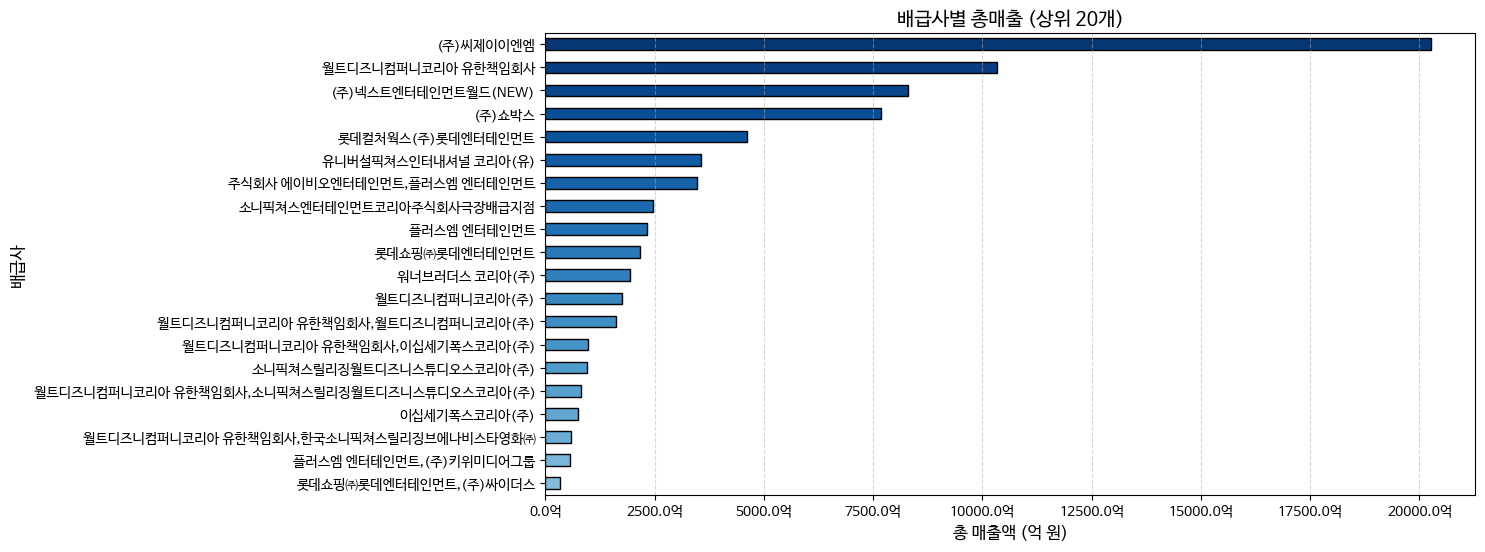

In [69]:
def to_billions(x, pos):
    return f'{x / 1e8:.1f}억'  # 1e8 = 1억 원



# 배급사별 총매출 계산 (내림차순 정렬)
total_revenue_by_distributor = highest_outliers.groupby("배급사")["전국매출액"].sum().sort_values(ascending=False)

#  푸른 계열 색상 설정 (높은 값이 진한 파란색)
colors = sns.color_palette("Blues", len(total_revenue_by_distributor))[::-1]


# 그래프 그리기
plt.figure(figsize=(12, 6))
ax = total_revenue_by_distributor.head(20).plot(kind="barh", color=colors, edgecolor="black")

# X축 단위를 억 원으로 변환
ax.xaxis.set_major_formatter(ticker.FuncFormatter(to_billions))

# 그래프 설정
plt.title("배급사별 총매출 (상위 20개)", fontsize=14)
plt.xlabel("총 매출액 (억 원)", fontsize=12)  # X축 라벨 수정
plt.ylabel("배급사", fontsize=12)
plt.gca().invert_yaxis()  # 배급사 순서 유지 (내림차순 정렬 유지)
plt.xticks(rotation=0)  # X축 라벨 회전 없애서 가독성 향상
plt.grid(axis="x", linestyle="--", alpha=0.5)  # 가로축에 점선 추가 (가독성 향상)

# 그래프 출력
plt.show()

#### ２-３-４. 이상치(수염위) 배급사별 평균 매출확인하기.


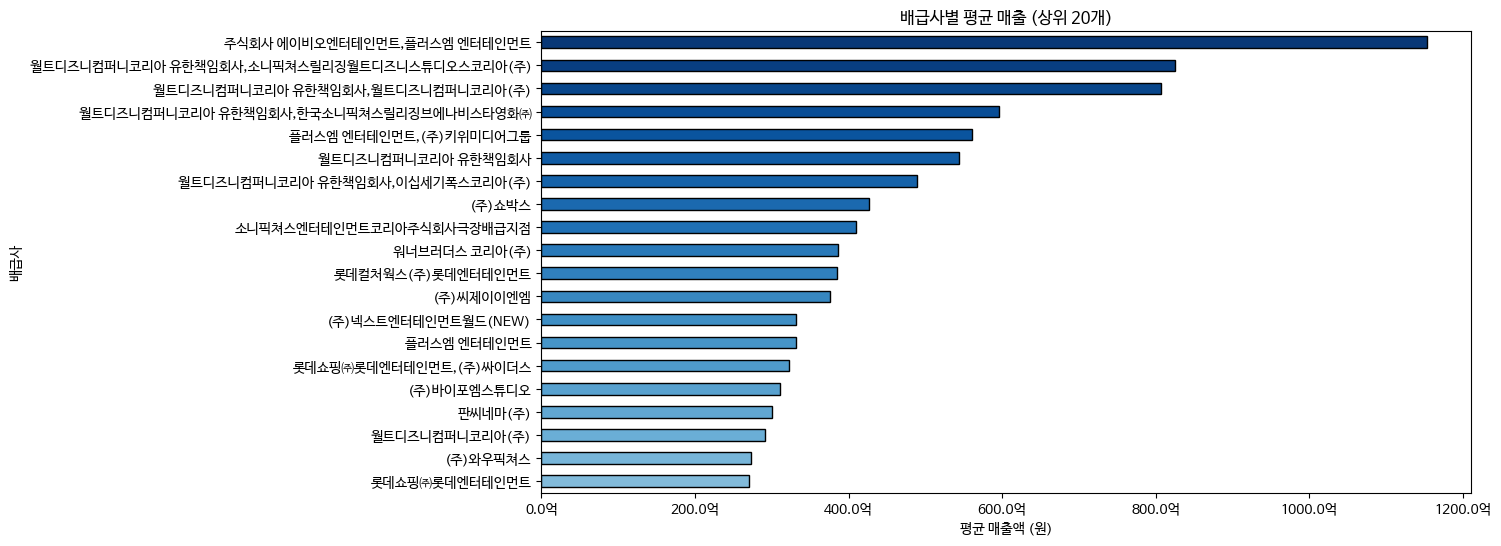

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

# 배급사별 평균 매출 계산
average_revenue_by_distributor = highest_outliers.groupby("배급사")["전국매출액"].mean().sort_values(ascending=False)

#  컬러맵 설정 (푸른 계열, 색상 진한 순서 유지)
colors = sns.color_palette("Blues", len(average_revenue_by_distributor))[::-1]

# 가로 막대 그래프 그리기
plt.figure(figsize=(12, 6))
ax = average_revenue_by_distributor.head(20).plot(kind="barh", color=colors, edgecolor="black")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(to_billions))


plt.title("배급사별 평균 매출 (상위 20개)")
plt.xlabel("평균 매출액 (원)")
plt.ylabel("배급사")
plt.gca().invert_yaxis()  # ✅ 가장 높은 평균 매출을 가진 배급사가 위로 오도록 유지
plt.show()



## 3️⃣ 정규성 검사
> 모델 선정 및 정제된 데이터 만들기 위한 과정

### 3-１-0.  Shapiro-Wilk Test (정규성 검정 테스트)
📌 **귀무가설(H₀): 데이터가 정규분포를 따른다.**

📌 **대립가설(H₁): 데이터가 정규분포를 따르지 않는다.**

✔ **p-value > 0.05** → 귀무가설 채택 → **정규성을 띌 가능성이 높음** ✅

✔ **p-value < 0.05** → 귀무가설 기각 → **정규성을 따르지 않을 가능성이 높음** ❌

In [71]:
#Shapiro-Wilk Test (정규성 검정)
stat, p_value = shapiro(filtered_kobis['전국관객수'])
print(f"Shapiro-Wilk Test 결과: p-value = {p_value}")

# 📌 정규성 검정 결과 해석
if p_value > 0.05:
    print(" 정규분포를 따를 가능성이 높음 (귀무가설 채택)")
else:
    print(" 정규분포를 따르지 않을 가능성이 높음 (귀무가설 기각)")

Shapiro-Wilk Test 결과: p-value = 1.5773505811545472e-72
 정규분포를 따르지 않을 가능성이 높음 (귀무가설 기각)


#### 3-１-0. INSIGHT

😳 극단적인 값으로 정규분포를 따를 가능성이 매우 적다. </br>
**선형 회귀(Linear Regression) 같은 정규성을 가정하는 모델을 적용할 경우, 변환(로그 변환 등)이 필요할 가능성이 높음**

### 3-１-１. 히스토그램 + KDE Plot

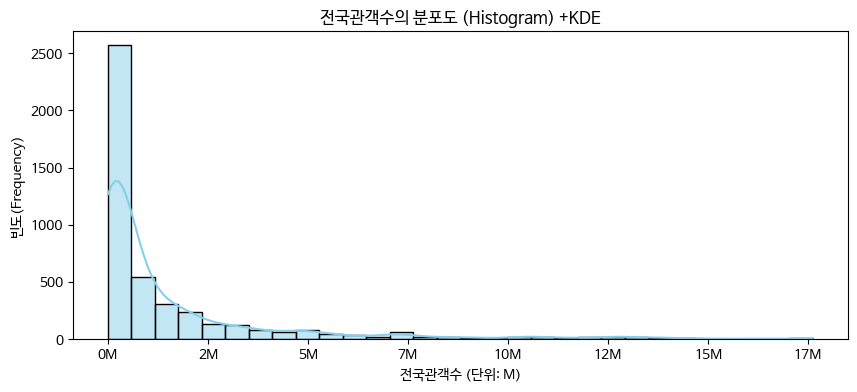

In [72]:
check_col = '전국관객수'
plt.figure(figsize = (10,4))
sns.histplot(filtered_kobis[check_col], bins= 30, kde = True, color = 'skyblue')
plt.title(f'{check_col}의 분포도 (Histogram) +KDE')

# 축 라벨 정하기.
plt.xlabel(f'{check_col} (단위: M)')
plt.ylabel('빈도(Frequency)')

# x축 단위 변환(백만)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1e6)}M'))


plt.show()

### 3-１-２. Q-Q Plot 정규성 확인

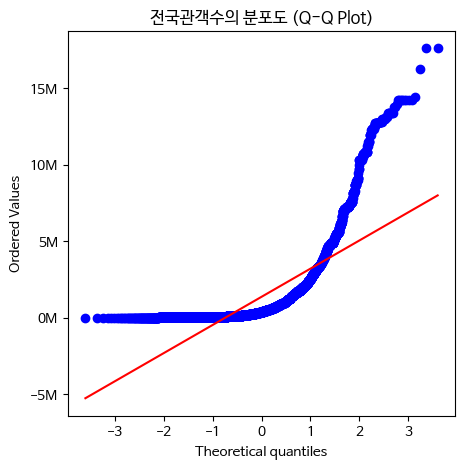

In [73]:
import scipy.stats as stats  # 위에서 정의했는데 없으니깐 오류나서 한번더함

plt.figure(figsize = (5,5))
stats.probplot(filtered_kobis[check_col], dist = 'norm', plot = plt)
plt.title(f'{check_col}의 분포도 (Q-Q Plot)')

# y축 단위 변환
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1e6)}M'))

plt.show()

#### 3-１-２. INSIGHT
> Theoretical Quantiles : 정규분포를 가정한 분위 수 </br>
   Ordered Values : 분석의 대상인 데이터('전국관객수')



**📝 고찰**
> QQPlot은 분위수끼리 비교하는 그래프이다.

* 파란 점이 빨간 기준선을 따를 수록 `정규분포`이다.
    * 현재 그래프는 많이 벗어나 있으므로 정규성을 띄고 있지 않다.

* 상위 분위수(우측)에서 값이 매우 커지는 패턴이 보인다.
    * 오른쪽으로 skewed 현상이 보인다.
    * 극단적인 이상치가 존재한다.


* 왼쪽 부분이 빨간 선 위에 위치한다.
    * 이는 `정규분포보다 큰 값들이 존재`한다는 것을 의미한다.
        * 왼쪽 꼬리가 길다(작은 값들이 정규 분포보다 크고 다양하게 퍼져있음)


👉 로그 변환 확인 필요</br>
👉또는 머신러닝 모델에서 정규성을 고려하지 않는 알고리즘 XGBoost, Random Forest) 등을 고려해야 함



#### 3-１-２.(첨부).skewed 예시

❗️ skewed 예시
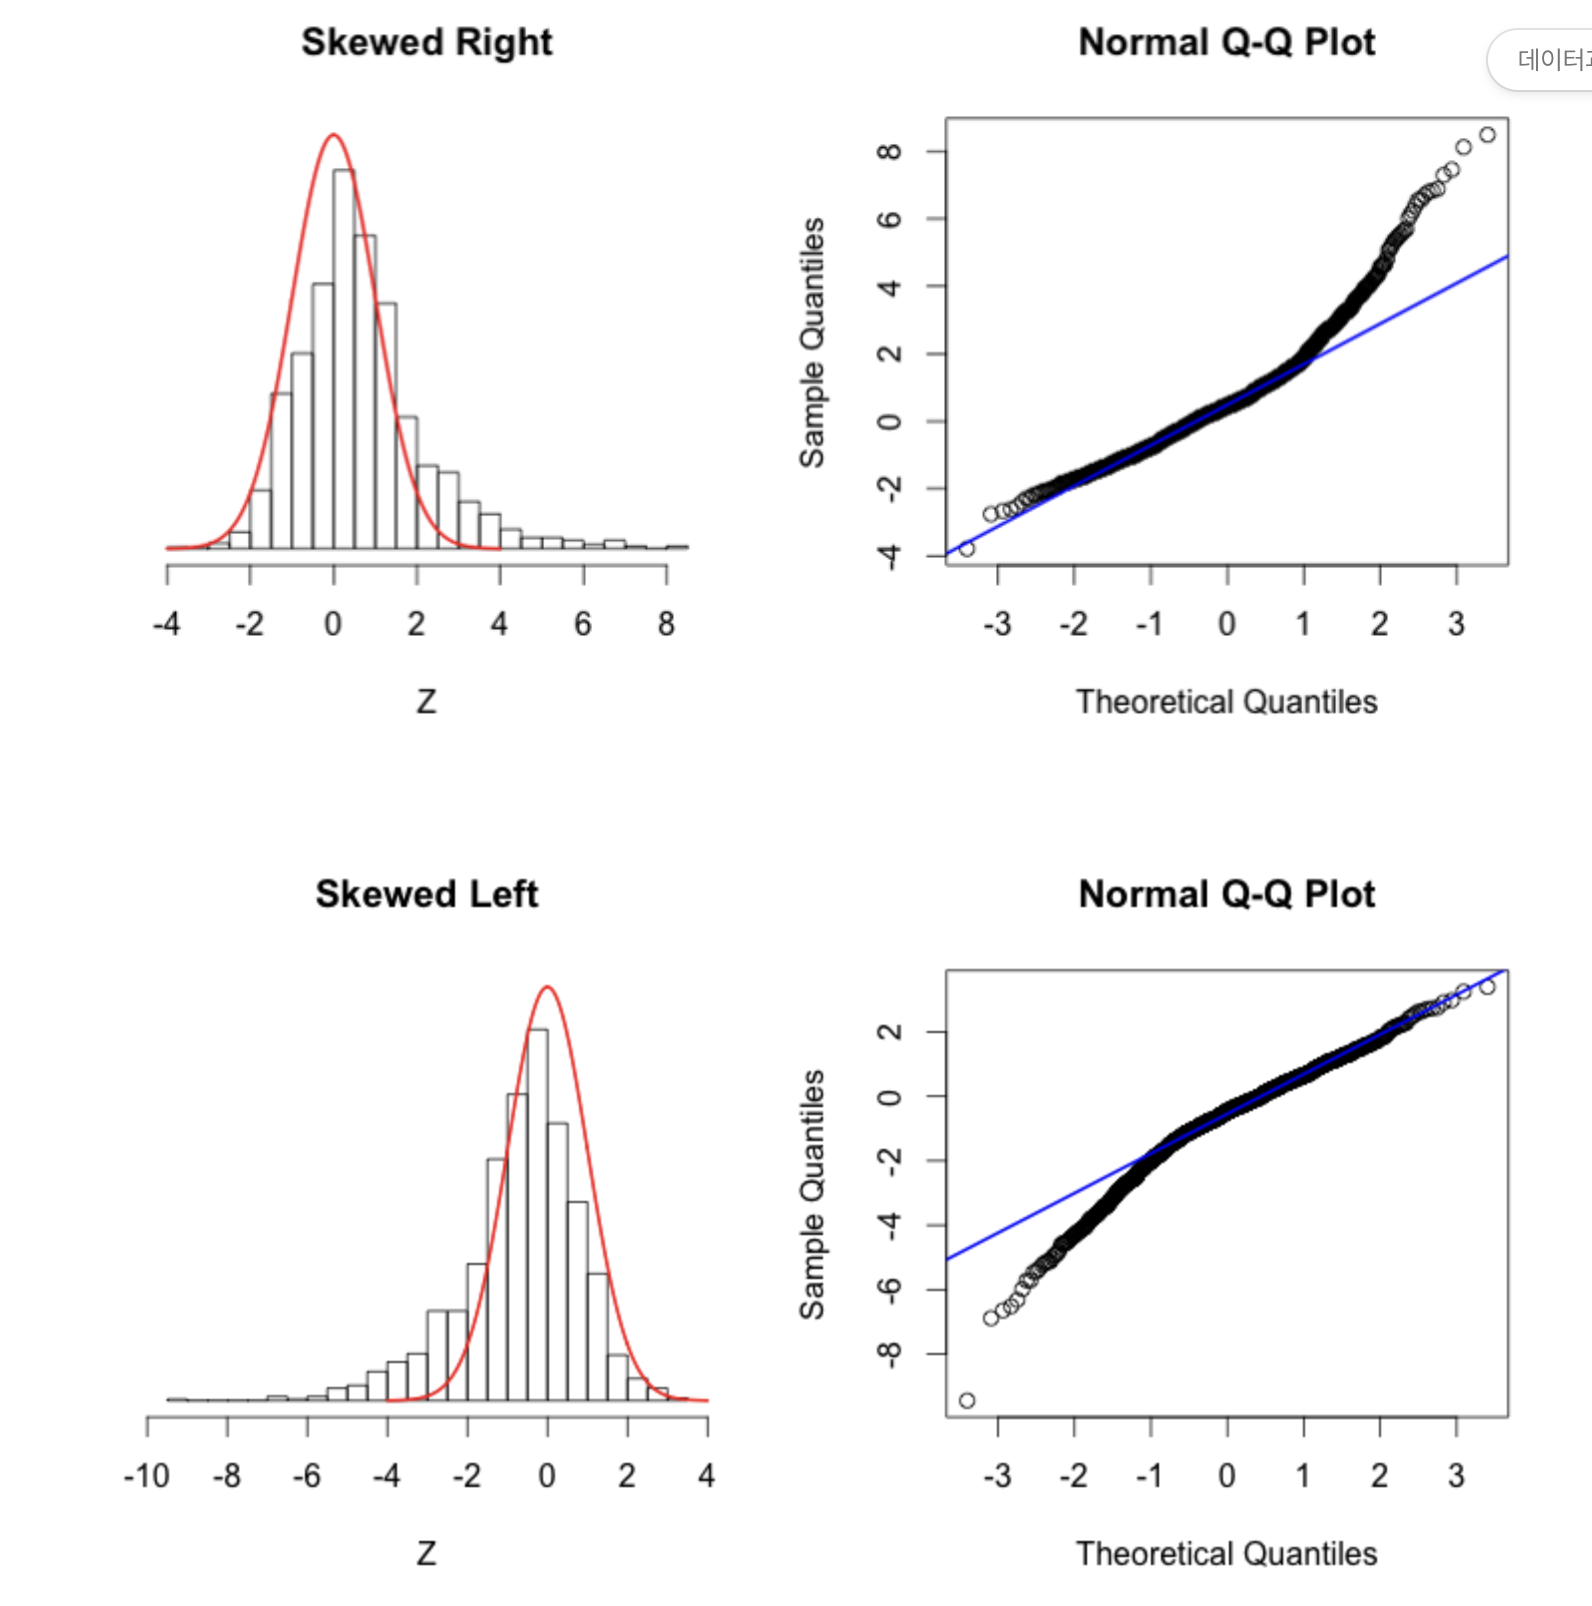

### 3-１-３. 박스플롯으로 살펴본 데이터(전체)

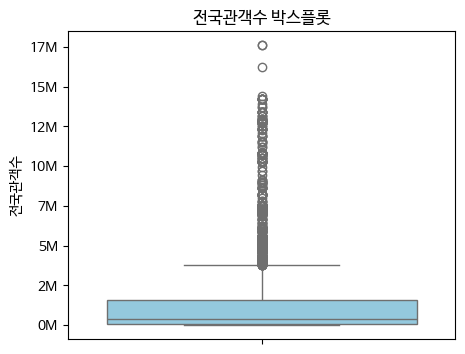

In [74]:
plt.figure(figsize=(5, 4))
sns.boxplot(y=filtered_kobis[check_col], color='skyblue')
plt.title(f"{check_col} 박스플롯")
plt.ylabel(check_col)

# y축 단위 변환
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1e6)}M'))
plt.show()

#### 3-１-３. INSIGHT

* 박스가 매우 낮은 위치에 존재함.
    * 아래 수염과 붙어있음(한쪽에 몰려 있다는 의미)
* 수염의 간격이 `비대칭`이다.
    * 데이터가 비대칭적으로 분포하고 있음을 의미한다.

* 이상치가 수염(위)를 기준으로 상당히 많음.
    * ❗️'전국관객수'는 극단적인 편차를 지니고 있으며, **일부 영화가 매우 높은 관객수를 기록**하고 있다.

👉 Q1(25%)와 최소값이 거의 같다(낮은 값들이 매우 많고, 분포가 비대칭적)</br>
👉 보통 이상치가 몇 개 정도 나오지만, 현재 그래프에서는 엄청나게 많은 원들이 위쪽에 분포</br>
👉 데이터가 극단적인 편차를 가지고 있으며, 평균값이 대표값으로 적절하지 않을 수도 있음!

## 4️⃣  모델링 분석.
* 문제에 맞는 적절한 분석 기법 모델 선택.
    * 데이터형태에 맞는 이상치 탐지 기법 사용

### 4-１. 이상치 제거하기.
> 현재까지의 과정으로 데이터의 특성이 다음과 같이 이루어져있다.


* '정규분포'를 띄지 않는 데이터.
    * 특정 구간에 모여있는 현상 발생.

🤨 그리하여 다음과 같이 아웃라이어를 탐지하고 제거하여 학습에 필요한 데이터를 얻고자 한다.

```
* 데이터가 특정 구간에 몰려 있다면 → 먼저 DBSCAN을 사용해 이상치를 탐색
* 이후 Modified Z-Score로 추가 확인 (강건한 이상치 탐지)
* 이상치 처리가 끝나고, 전체적인 분포 조정이 필요하면 로그 변환 적용
```

#### ４-１-１. DBSCAN : 밀도 기반 탐색
최적의 파라미터(eps, min_samples)를 찾기 위해 다음과 같은 작업을 먼저 진행한다.
* 적절한 eps 값을 찾기 위해 k-distance graph 활용

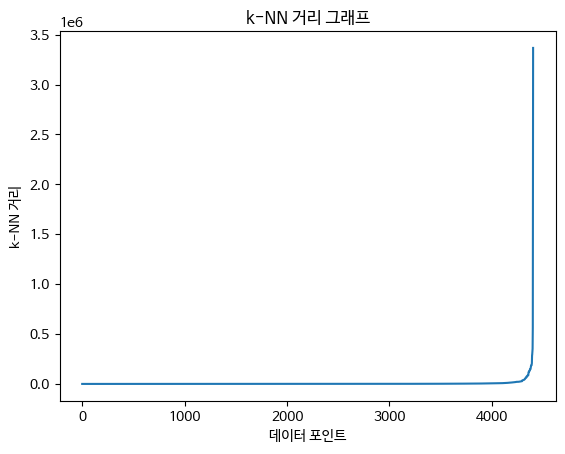

In [77]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=5)


neighbors_fit = neighbors.fit(filtered_kobis[["전국관객수"]])
distances, indices = neighbors_fit.kneighbors(filtered_kobis[["전국관객수"]])

distances = np.sort(distances[:, 4])  # 5번째 이웃 거리 정렬
plt.plot(distances)
plt.xlabel("데이터 포인트")
plt.ylabel("k-NN 거리")
plt.title("k-NN 거리 그래프")
plt.show()
